Actividad 4

In [4]:
!apt-get install gnuplot

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following additional packages will be installed:
  aglfn at-spi2-core gnuplot-data gnuplot-qt gsettings-desktop-schemas
  libatk-bridge2.0-0 libatk1.0-0 libatk1.0-data libatspi2.0-0
  libdouble-conversion3 libevdev2 libgtk-3-0 libgtk-3-bin libgtk-3-common
  libgudev-1.0-0 libinput-bin libinput10 liblua5.4-0 libmd4c0 libmtdev1
  libnotify4 libqt5core5a libqt5dbus5 libqt5gui5 libqt5network5
  libqt5printsupport5 libqt5svg5 libqt5widgets5 librsvg2-common libwacom-bin
  libwacom-common libwacom9 libwxbase3.0-0v5 libwxgtk3.0-gtk3-0v5
  libxcb-icccm4 libxcb-image0 libxcb-keysyms1 libxcb-render-util0 libxcb-util1
  libxcb-xinerama0 libxcb-xinput0 libxcb-xkb1 libxcomposite1
  libxkbcommon-x11-0 libxtst6 qt5-gtk-platformtheme qttranslations5-l10n
  session-migration
Suggested packages:
  gnuplot-doc gvfs gnome-shell | notification-daemon qt5-image-formats-plugins
  qtwayland5
The following NEW p

In [2]:
import pandas as pd
import subprocess
from IPython.display import Image, display

df = pd.read_excel('/content/datos/IE_P_CODMOD.xlsx')

top_ugel = df['DRE_UGEL'].value_counts().head(10).reset_index()
top_ugel.to_csv('datos_ugel.dat', sep='\t', index=False, header=False)

niveles = df['NIV_MOD'].value_counts().reset_index()
niveles.to_csv('datos_nivel.dat', sep='\t', index=False, header=False)

coordenadas = df[['X_LONGITUD', 'Y_LATITUD']].dropna()
coordenadas.to_csv('datos_mapa.dat', sep='\t', index=False, header=False)

1.Top 10 DRE/UGEL

In [37]:
script_g1 = """
set terminal png
set output 'grafico1_ugel.png'
set title "Top 10 DRE/UGEL con Mayor Cantidad de Locales Educativos"
set ylabel "Cantidad de Colegios"
set grid

plot 'datos_ugel.dat' using 0:2:xtic(1) with impulses lw 5 lc rgb "blue" title "Locales Educativos"
"""
with open('script1.plt', 'w') as f: f.write(script_g1)

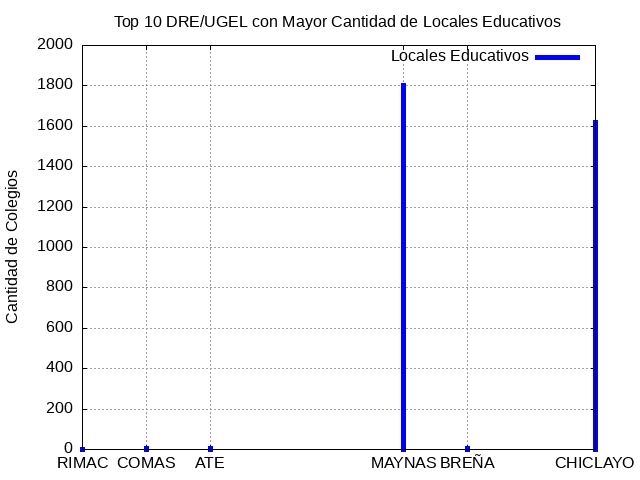

In [34]:
subprocess.run(['gnuplot', 'script1.plt'])
Image('grafico1_ugel.png')

Evidencia la concentración de la infraestructura educativa por jurisdicción administrativa. Se destacan las DRE/UGEL principales que gestionan el mayor volumen de colegios, lo cual es un indicador directo de las zonas con mayor demanda de gestión y supervisión estatal

2.Distribución por Nivel/Modalidad

In [23]:
script_g2 = """
set terminal png
set output 'grafico2_nivel.png'
set title "Distribución de Servicios Educativos por Nivel/Modalidad"
set ylabel "Cantidad de Servicios"
set grid
set style fill solid 0.5
set bmargin 8

plot 'datos_nivel.dat' using 0:2:xtic(1) with steps lw 2 lc rgb "red" title "Cantidad por Nivel"
"""
with open('script2.plt', 'w') as f: f.write(script_g2)

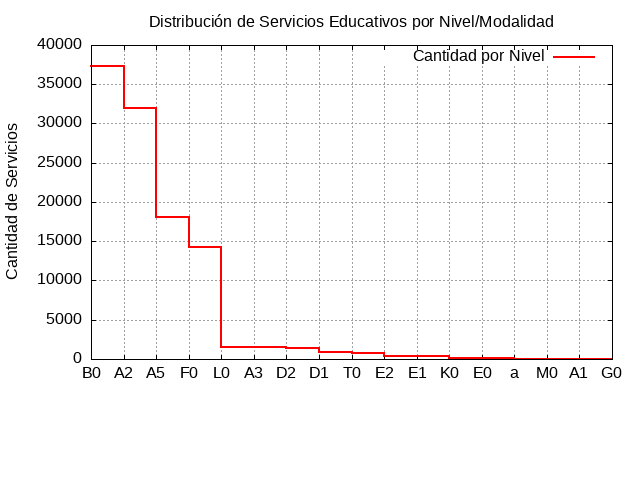

In [24]:
subprocess.run(['gnuplot', 'script2.plt'])
Image('grafico2_nivel.png')

Analizamos la oferta educativa según su nivel y modalidad

3.Mapa de Dispersión Geográfica

In [35]:
script_g3 = """
set terminal png
set output 'grafico3_mapa.png'
set title "Distribución Geográfica de Locales Educativos"
set xlabel "Longitud"
set ylabel "Latitud"
set grid

plot 'datos_mapa.dat' using 1:2 title "Ubicación del Colegio"
"""
with open('script3.plt', 'w') as f: f.write(script_g3)

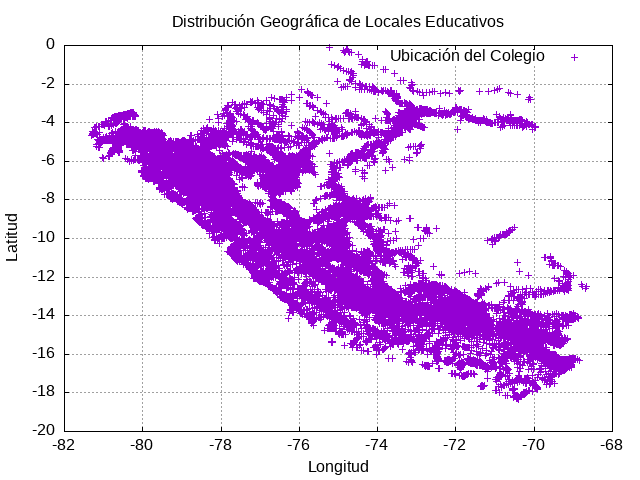

In [36]:
subprocess.run(['gnuplot', 'script3.plt'])
Image('grafico3_mapa.png')

El Gráfico 3 muestra los datos de geolocalización (Latitud y Longitud) del dataset para generar un mapa de dispersión. La densidad de los puntos revela gráficamente la concentración de colegios públicos, delineando la geografía de la zona analizada y mostrando claramente las áreas urbanas densas frente a las zonas rurales dispersas.